In [1]:
import os 
import numpy as np
import json
from pathlib import Path
import re


In [ ]:
"""
CVPR single-column plot formatting for history contamination figures.
Drop this into your notebook after loading results dicts.

CVPR column width: 3.25 in (single), 6.875 in (double/full width)
Save as PDF -> \includegraphics in LaTeX for vector output.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import rcParams

# ── Global RC settings for CVPR ──────────────────────────────
rcParams.update({
    "font.family":       "serif",
    "font.size":         7,
    "axes.titlesize":    7,
    "axes.labelsize":    7,
    "xtick.labelsize":   6,
    "ytick.labelsize":   6,
    "legend.fontsize":   5.5,
    "figure.dpi":        300,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

COL_W   = 3.25
FULL_W  = 6.875
bins    = np.linspace(0, 1, 11)

MODE_LABELS = {
    "rel_fixed_easy":   "Rel Easy",
    "rel_fixed_medium": "Rel Med",
    "rel_fixed_hard":   "Rel Hard",
    "global_easy":      "Glo Easy",
    "global_medium":    "Glo Med",
    "global_hard":      "Glo Hard",
}

COLORS = {
    "rel_fixed_easy":   "#1f77b4",
    "rel_fixed_medium": "#ff7f0e",
    "rel_fixed_hard":   "#2ca02c",
    "global_easy":      "#d62728",
    "global_medium":    "#9467bd",
    "global_hard":      "#8c564b",
}


def _build_heatmap_row_normalized(results, names):
    """Build row-normalized heatmaps (each row sums to ~1)."""
    heatmaps = {}
    global_max = 0
    for name in names:
        r = results[name]
        hm = []
        for k, recs in zip(r["k"], r["records"]):
            if k == 0:
                continue
            scores = np.array([x["score"] for x in recs])
            hist, _ = np.histogram(scores, bins=bins, density=True)
            hm.append(hist)
        hm = np.array(hm)
        row_sums = hm.sum(axis=1, keepdims=True) + 1e-12
        hm = hm / row_sums
        heatmaps[name] = hm
        global_max = max(global_max, hm.max())
    return heatmaps, global_max


# ═════════════════════════════════════════════════════════════
#  COMBINED FIGURE: ASR curve (top) + heatmap row (bottom)
#  For CP4F / MSF (4-frame detectors)
# ═════════════════════════════════════════════════════════════
def plot_4frame_combined(results, detector_prefix, save_path=None):
    modes = [
        "rel_fixed_easy", "rel_fixed_medium", "rel_fixed_hard",
        "global_easy",    "global_medium",    "global_hard",
    ]
    names = [f"{detector_prefix}_{m}" for m in modes]

    heatmaps, vmax = _build_heatmap_row_normalized(results, names)

    fig = plt.figure(figsize=(COL_W, 3.8))

    # 3 rows: ASR line plot, heatmap row 1 (rel), heatmap row 2 (glo)
    gs = fig.add_gridspec(
        3, 3,
        height_ratios=[1.4, 1, 1],
        hspace=0.50, wspace=0.30,
        left=0.12, right=0.82, top=0.95, bottom=0.08,
    )

    # ── Top: ASR vs k ──
    ax_asr = fig.add_subplot(gs[0, :])
    for name, mode in zip(names, modes):
        r = results[name]
        ks  = np.array(r["k"])
        asr = np.array(r["asr"])
        mask = ks > 0
        ax_asr.plot(
            ks[mask], asr[mask],
            marker="o", markersize=3, linewidth=1,
            color=COLORS[mode], label=MODE_LABELS[mode],
        )
    ax_asr.set_xlabel("k (history contamination)")
    ax_asr.set_ylabel("ASR")
    ax_asr.set_xticks([1, 2, 3, 4])
    # legend: single column, to the right of the plot
    ax_asr.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        ncol=1, frameon=False,
    )
    ax_asr.grid(True, linewidth=0.3, alpha=0.5)

    # ── Middle row: 3 rel_fixed heatmaps ──
    # ── Bottom row: 3 global heatmaps ──
    k_labels = [1, 2, 3, 4]
    for col in range(3):
        for row_offset, mode_offset in enumerate([0, 3]):  # rel=0..2, glo=3..5
            idx = mode_offset + col
            name = names[idx]
            mode = modes[idx]
            ax = fig.add_subplot(gs[1 + row_offset, col])
            hm = heatmaps[name]
            im = ax.imshow(
                hm, aspect="auto", origin="lower",
                extent=[0, 1, 0.5, 4.5],
                cmap="magma", vmin=0, vmax=vmax,
                interpolation="nearest",
            )
            ax.set_yticks(k_labels)
            ax.set_title(MODE_LABELS[mode], pad=2)
            ax.set_xticks([0, 0.5, 1])
            if col == 0:
                ax.set_ylabel("k")
            else:
                ax.set_yticklabels([])
            if row_offset == 1:
                ax.set_xlabel("score")

    # colorbar to the right of heatmaps
    cax = fig.add_axes([0.84, 0.08, 0.015, 0.38])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("density")

    if save_path:
        fig.savefig(save_path)
        print(f"Saved → {save_path}")
    plt.show()


# ═════════════════════════════════════════════════════════════
#  COMBINED FIGURE: ASR curve (top) + heatmap row (bottom)
#  For PTT (32-frame)
# ═════════════════════════════════════════════════════════════
def plot_ptt_combined(results, save_path=None):
    modes = [
        "rel_fixed_easy", "rel_fixed_medium", "rel_fixed_hard",
        "global_easy",    "global_medium",    "global_hard",
    ]
    names = [f"ptt_{m}" for m in modes]

    heatmaps, vmax = _build_heatmap_row_normalized(results, names)

    fig = plt.figure(figsize=(FULL_W, 4.2))

    # ASR plot spans full width
    ax_asr = fig.add_axes([0.07, 0.72, 0.78, 0.25])  # [left, bottom, width, height]
    for name, mode in zip(names, modes):
        r = results[name]
        ks  = np.array(r["k"])
        asr = np.array(r["asr"])
        mask = ks > 0
        ax_asr.plot(
            ks[mask], asr[mask],
            marker="o", markersize=2, linewidth=0.9,
            color=COLORS[mode], label=MODE_LABELS[mode],
        )
    ax_asr.set_xlabel("k (history contamination)")
    ax_asr.set_ylabel("ASR")
    ax_asr.xaxis.set_major_locator(ticker.MultipleLocator(4))
    ax_asr.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        ncol=1, frameon=False,
    )
    ax_asr.grid(True, linewidth=0.3, alpha=0.5)

    # Heatmaps: constrain to ~column width, centered
    hm_left   = 0.22          # left edge of heatmap block
    hm_width  = 0.45          # total width for 3 columns (~COL_W / FULL_W)
    hm_gap    = 0.03          # horizontal gap between panels
    panel_w   = (hm_width - 2 * hm_gap) / 3
    row_h     = 0.22          # height of each heatmap row
    row_gap   = 0.08          # vertical gap between rows
    bot_row_y = 0.05          # bottom of lower row
    top_row_y = bot_row_y + row_h + row_gap

    for col in range(3):
        x0 = hm_left + col * (panel_w + hm_gap)
        for row_offset, mode_offset in enumerate([0, 3]):
            idx = mode_offset + col
            name = names[idx]
            mode = modes[idx]
            y0 = top_row_y if row_offset == 0 else bot_row_y
            ax = fig.add_axes([x0, y0, panel_w, row_h])
            hm = heatmaps[name]
            n_k = hm.shape[0]
            im = ax.imshow(
                hm, aspect="auto", origin="lower",
                extent=[0, 1, 0.5, n_k + 0.5],
                cmap="magma", vmin=0, vmax=vmax,
                interpolation="nearest",
            )
            ax.set_title(MODE_LABELS[mode], pad=2)
            ax.set_xticks([0, 0.5, 1])
            ax.yaxis.set_major_locator(ticker.MultipleLocator(8))
            if col == 0:
                ax.set_ylabel("k")
            else:
                ax.set_yticklabels([])
            if row_offset == 1:
                ax.set_xlabel("score")

    # colorbar next to heatmaps
    cax = fig.add_axes([hm_left + hm_width + 0.02, bot_row_y, 0.012, 2 * row_h + row_gap])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("density")

    if save_path:
        fig.savefig(save_path)
        print(f"Saved → {save_path}")
    plt.show()

# ═════════════════════════════════════════════════════════════
#  GLOBAL ASR BAR CHART  (single column)
# ═════════════════════════════════════════════════════════════
def plot_global_asr_bars(global_asr, save_path=None):
    modes = [
        "rel_fixed_easy", "rel_fixed_medium", "rel_fixed_hard",
        "global_easy",    "global_medium",    "global_hard",
    ]
    detectors = ["cp", "cp4f", "msf", "ptt"]
    det_labels = ["CP", "CP4F", "MSF", "PTT"]
    det_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

    asr_by_det = {d: [] for d in detectors}
    for m in modes:
        for d in detectors:
            val = 0
            for entry in global_asr:
                if entry["name"] == f"{d}_{m}":
                    val = entry["asr_vehicle"]
            asr_by_det[d].append(val)

    x = np.arange(len(modes))
    w = 0.18
    offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * w

    fig, ax = plt.subplots(figsize=(COL_W, 1.8))
    for det, off, color, label in zip(detectors, offsets,
                                       det_colors, det_labels):
        ax.bar(x + off, asr_by_det[det], w,
               color=color, label=label, edgecolor="white",
               linewidth=0.3)

    ax.set_xticks(x)
    ax.set_xticklabels([MODE_LABELS[m] for m in modes], rotation=30,
                        ha="right")
    ax.set_ylabel("Vehicle ASR")
    ax.legend(ncol=4, loc="upper left", frameon=False)
    ax.set_ylim(0, 0.55)
    ax.grid(axis="y", linewidth=0.3, alpha=0.5)

    if save_path:
        fig.savefig(save_path)
        print(f"Saved → {save_path}")
    plt.show()


# ═════════════════════════════════════════════════════════════
#  SCORE DENSITY HISTOGRAMS  (full width, 2x3 grid)
# ═════════════════════════════════════════════════════════════
def plot_score_densities(global_asr, save_path=None):
    modes = [
        "rel_fixed_easy", "rel_fixed_medium", "rel_fixed_hard",
        "global_easy",    "global_medium",    "global_hard",
    ]
    detectors  = ["cp", "cp4f", "msf", "ptt"]
    det_labels = ["CP", "CP4F", "MSF", "PTT"]
    det_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

    score_bins = np.linspace(0, 1, 25)

    fig, axes = plt.subplots(2, 3, figsize=(FULL_W, 2.4),
                              sharex=True, sharey=True)

    for idx, mode in enumerate(modes):
        ax = axes[idx // 3, idx % 3]
        for det, color, label in zip(detectors, det_colors, det_labels):
            scores = []
            for entry in global_asr:
                if entry["name"] == f"{det}_{mode}":
                    scores = entry["scores_vehicle"]
            if len(scores) > 0:
                ax.hist(scores, bins=score_bins, density=True,
                        histtype="step", linewidth=0.8,
                        color=color, label=label)
        ax.set_title(MODE_LABELS[mode], pad=2)
        ax.set_xlim(0, 1)
        if idx // 3 == 1:
            ax.set_xlabel("score")
        if idx % 3 == 0:
            ax.set_ylabel("density")

    axes[0, 2].legend(loc="upper right", frameon=False)
    fig.tight_layout(h_pad=0.6, w_pad=0.4)

    if save_path:
        fig.savefig(save_path)
        print(f"Saved → {save_path}")
    plt.show()


# ─────────────────────────────────────────────────────────────
# Usage:
# ─────────────────────────────────────────────────────────────
# plot_global_asr_bars(global_asr, save_path="fig_global_asr.pdf")
# plot_score_densities(global_asr, save_path="fig_score_density.pdf")
# plot_4frame_combined(results, "cp4f", save_path="fig_cp4f_history.pdf")
# plot_4frame_combined(results, "msf",  save_path="fig_msf_history.pdf")
# plot_ptt_combined(results,            save_path="fig_ptt_history.pdf")

In [6]:
np.linspace(0, 1, 11)

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [7]:
global_metrics_directory = os.listdir('metrics_final')
local_metrics_directory_msf = os.listdir('metrics_local_final_msf')
local_metrics_directory_ptt = os.listdir('metrics_local_final_ptt')
local_metrics_directory_cp4f = os.listdir('metrics_local_final_cp4f')
global_metrics_files =[f'metrics_final/{f}' for f in global_metrics_directory if f.endswith('.json')] 
local_metrics_files_msf = [f'metrics_local_final_msf/{f}' for f in local_metrics_directory_msf if f.endswith('.json')]
local_metrics_files_ptt = [f'metrics_local_final_ptt/{f}' for f in local_metrics_directory_ptt if f.endswith('.json')]
local_metrics_files_cp4f = [f'metrics_local_final_cp4f/{f}' for f in local_metrics_directory_cp4f if f.endswith('.json')]

with open(global_metrics_files[0], 'r') as f:
    global_metrics = json.load(f)
type(global_metrics)

dict

In [8]:
len(global_metrics_files)

34

In [9]:
global_metrics_files = [file for file in global_metrics_files if 'random' not in file and 'sanity' not in file and 'copy' not in file]
local_metrics_files_msf = [file for file in local_metrics_files_msf if 'local' in file]
local_metrics_files_ptt = [file for file in local_metrics_files_ptt if 'local' in file]
local_metrics_files_cp4f = [file for file in local_metrics_files_cp4f if 'local' in file]
local_metrics_files_msf

['metrics_local_final_msf/msf_rel_fixed_medium_local.json',
 'metrics_local_final_msf/msf_rel_fixed_easy_local.json',
 'metrics_local_final_msf/msf_rel_fixed_hard_local.json',
 'metrics_local_final_msf/msf_global_easy_local.json',
 'metrics_local_final_msf/msf_global_medium_local.json',
 'metrics_local_final_msf/msf_global_hard_local.json']

In [10]:
def vehicle_ap_aph(metrics):
    # return metrics in the form [l1 ap, l1 aph, l2 ap, l2aph]
    L1ap = metrics['OBJECT_TYPE_TYPE_VEHICLE_LEVEL_1/AP']
    L1aph = metrics['OBJECT_TYPE_TYPE_VEHICLE_LEVEL_1/APH']
    L2ap = metrics['OBJECT_TYPE_TYPE_VEHICLE_LEVEL_2/AP']
    L2aph = metrics['OBJECT_TYPE_TYPE_VEHICLE_LEVEL_2/APH']
    return 100*np.array([L1ap, L1aph, L2ap, L2aph])
def pedestrian_ap_aph(metrics):
    # return metrics in the form [l1 ap, l1 aph, l2 ap, l2aph]
    L1ap = metrics['OBJECT_TYPE_TYPE_PEDESTRIAN_LEVEL_1/AP']
    L1aph = metrics['OBJECT_TYPE_TYPE_PEDESTRIAN_LEVEL_1/APH']
    L2ap = metrics['OBJECT_TYPE_TYPE_PEDESTRIAN_LEVEL_2/AP']
    L2aph = metrics['OBJECT_TYPE_TYPE_PEDESTRIAN_LEVEL_2/APH']
    return 100*np.array([L1ap, L1aph, L2ap, L2aph])
def cyclist_ap_aph(metrics):
    # return metrics in the form [l1 ap, l1 aph, l2 ap, l2aph]
    L1ap = metrics['OBJECT_TYPE_TYPE_CYCLIST_LEVEL_1/AP']
    L1aph = metrics['OBJECT_TYPE_TYPE_CYCLIST_LEVEL_1/APH']
    L2ap = metrics['OBJECT_TYPE_TYPE_CYCLIST_LEVEL_2/AP']
    L2aph = metrics['OBJECT_TYPE_TYPE_CYCLIST_LEVEL_2/APH']
    return 100*np.array([L1ap, L1aph, L2ap, L2aph])
def overall_map_maph(metrics):
    vehicle = vehicle_ap_aph(metrics)
    pedestrian = pedestrian_ap_aph(metrics)
    cyclist = cyclist_ap_aph(metrics)
    l1map = (vehicle[0] + pedestrian[0] + cyclist[0]) / 3
    l1maph = (vehicle[1] + pedestrian[1] + cyclist[1]) / 3
    l2map = (vehicle[2] + pedestrian[2] + cyclist[2]) / 3
    l2maph = (vehicle[3] + pedestrian[3] + cyclist[3]) / 3
    return np.array([round(l1map, 1), round(l1maph, 1), round(l2map, 1), round(l2maph, 1)])

In [11]:
global_metrics_dict = {}
for file in global_metrics_files:
    with open(file, 'r') as f:
        global_metrics = json.load(f)
    name = Path(file).stem                      # "msf_rel_fixed_easy_20260307_225527"
    base = re.sub(r'_\d{8}_\d{6}$', '', name)  # "msf_rel_fixed_easy
    l1map, l1maph, l2map, l2maph = overall_map_maph(global_metrics)
    v_metrics = vehicle_ap_aph(global_metrics)
    c_metrics = cyclist_ap_aph(global_metrics)
    p_metrics = pedestrian_ap_aph(global_metrics)
    
    metrics_dict = {
        'l1_map_maph' : f'{l1map}/{l1maph}',
        'l2_map_maph' : f'{l2map}/{l2maph}',
        'l1_v_ap_aph' : f'{round(v_metrics[0], 1)}/{round(v_metrics[1], 1)}',
        'l2_v_ap_aph' : f'{round(v_metrics[2], 1)}/{round(v_metrics[3], 1)}',
        'l1_c_ap_aph' : f'{round(c_metrics[0], 1)}/{round(c_metrics[1], 1)}',
        'l2_c_ap_aph' : f'{round(c_metrics[2], 1)}/{round(c_metrics[3], 1)}',
        'l1_p_ap_aph' : f'{round(p_metrics[0], 1)}/{round(p_metrics[1], 1)}',
        'l2_p_ap_aph' : f'{round(p_metrics[2], 1)}/{round(p_metrics[3], 1)}'
    }
    global_metrics_dict[base] = metrics_dict
    

In [12]:
prefix_order = {"cp": 0, "cp4f": 1, "msf": 2, "ptt": 3}
suffix_order = {
    "clean": 0,
    "rel_fixed_easy": 1,
    "rel_fixed_medium": 2,
    "rel_fixed_hard": 3,
    "global_easy": 4,
    "global_medium": 5,
    "global_hard": 6,
}

def sort_key(k: str):
    # split "msf_global_hard" -> "msf", "global_hard"
    prefix, suffix = k.split("_", 1)
    return (prefix_order.get(prefix, 99), suffix_order.get(suffix, 99), k)
ordered_data = dict(sorted(global_metrics_dict.items(), key=lambda kv: sort_key(kv[0])))


In [13]:
import pandas as pd

# use your already-ordered dict from earlier step
# ordered_data = dict(sorted(...))

rows = []
for outer_key, m in ordered_data.items():
    detector, mode = outer_key.split("_", 1)  # "msf_rel_fixed_easy" -> ("msf", "rel_fixed_easy")

    rows.append({
        ("", "Detector"): detector,
        ("", "Mode"): mode,

        ("mAP/mAPH", "L1"): m["l1_map_maph"],
        ("mAP/mAPH", "L2"): m["l2_map_maph"],

        ("Vehicle AP/APH", "L1"): m["l1_v_ap_aph"],
        ("Vehicle AP/APH", "L2"): m["l2_v_ap_aph"],

        ("Pedestrian AP/APH", "L1"): m["l1_p_ap_aph"],
        ("Pedestrian AP/APH", "L2"): m["l2_p_ap_aph"],

        ("Cyclist AP/APH", "L1"): m["l1_c_ap_aph"],
        ("Cyclist AP/APH", "L2"): m["l2_c_ap_aph"],
    })

df = pd.DataFrame(rows)

# keep explicit column order
df = df[
    [
        ("", "Detector"),
        ("", "Mode"),
        ("mAP/mAPH", "L1"), ("mAP/mAPH", "L2"),
        ("Vehicle AP/APH", "L1"), ("Vehicle AP/APH", "L2"),
        ("Pedestrian AP/APH", "L1"), ("Pedestrian AP/APH", "L2"),
        ("Cyclist AP/APH", "L1"), ("Cyclist AP/APH", "L2"),
    ]
]

# df.to_excel("global_metrics.xlsx")


In [14]:
global_asr_path = 'asr/asr.pkl'
import pickle as pkl
with open(global_asr_path, 'rb') as f:
    global_asr = pkl.load(f)
type(global_asr)

list

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

modes = [
    "rel_fixed_easy",
    "rel_fixed_medium",
    "rel_fixed_hard",
    "global_easy",
    "global_medium",
    "global_hard"
]

cp = []
cp4f = []
msf = []
ptt = []

for m in modes:
    for entry in global_asr:
        if entry["name"] == f"cp_{m}":
            cp.append(entry["asr_vehicle"])
        if entry["name"] == f"cp4f_{m}":
            cp4f.append(entry["asr_vehicle"])
        if entry["name"] == f"msf_{m}":
            msf.append(entry["asr_vehicle"])
        if entry["name"] == f"ptt_{m}":
            ptt.append(entry["asr_vehicle"])

x = np.arange(len(modes))
w = 0.2  # narrower bars for 4 groups

plt.figure(figsize=(10,4))

plt.bar(x - 1.5*w, cp,   w, label="CenterPoint")
plt.bar(x - 0.5*w, cp4f, w, label="CenterPoint 4F")
plt.bar(x + 0.5*w, msf,  w, label="MSF")
plt.bar(x + 1.5*w, ptt,  w, label="PTT")

plt.xticks(x, modes, rotation=30)
plt.ylabel("Vehicle ASR")
plt.title("Attack Success Rate")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

modes = [
    "rel_fixed_easy",
    "rel_fixed_medium",
    "rel_fixed_hard",
    "global_easy",
    "global_medium",
    "global_hard"
]

rows = []

for m in modes:
    row = {"mode": m}
    for entry in global_asr:
        if entry["name"] == f"cp_{m}":
            row["CenterPoint"] = entry["asr_vehicle"]
        if entry["name"] == f"cp4f_{m}":
            row["CenterPoint 4F"] = entry["asr_vehicle"]
        if entry["name"] == f"msf_{m}":
            row["MSF"] = entry["asr_vehicle"]
        if entry["name"] == f"ptt_{m}":
            row["PTT"] = entry["asr_vehicle"]
    rows.append(row)

df = pd.DataFrame(rows).set_index("mode")
df = df.round(2)
df = df[["CenterPoint", "CenterPoint 4F", "MSF", "PTT"]]
print(df)

                  CenterPoint  CenterPoint 4F   MSF   PTT
mode                                                     
rel_fixed_easy           0.11            0.12  0.13  0.14
rel_fixed_medium         0.12            0.22  0.29  0.26
rel_fixed_hard           0.10            0.29  0.35  0.35
global_easy              0.16            0.18  0.19  0.21
global_medium            0.30            0.36  0.41  0.44
global_hard              0.32            0.45  0.46  0.50


# density: what fraction of false positive detections fall into that score bins?

In [13]:
bins = np.linspace(0, 1, 21)  # 10 bins from 0 to 1

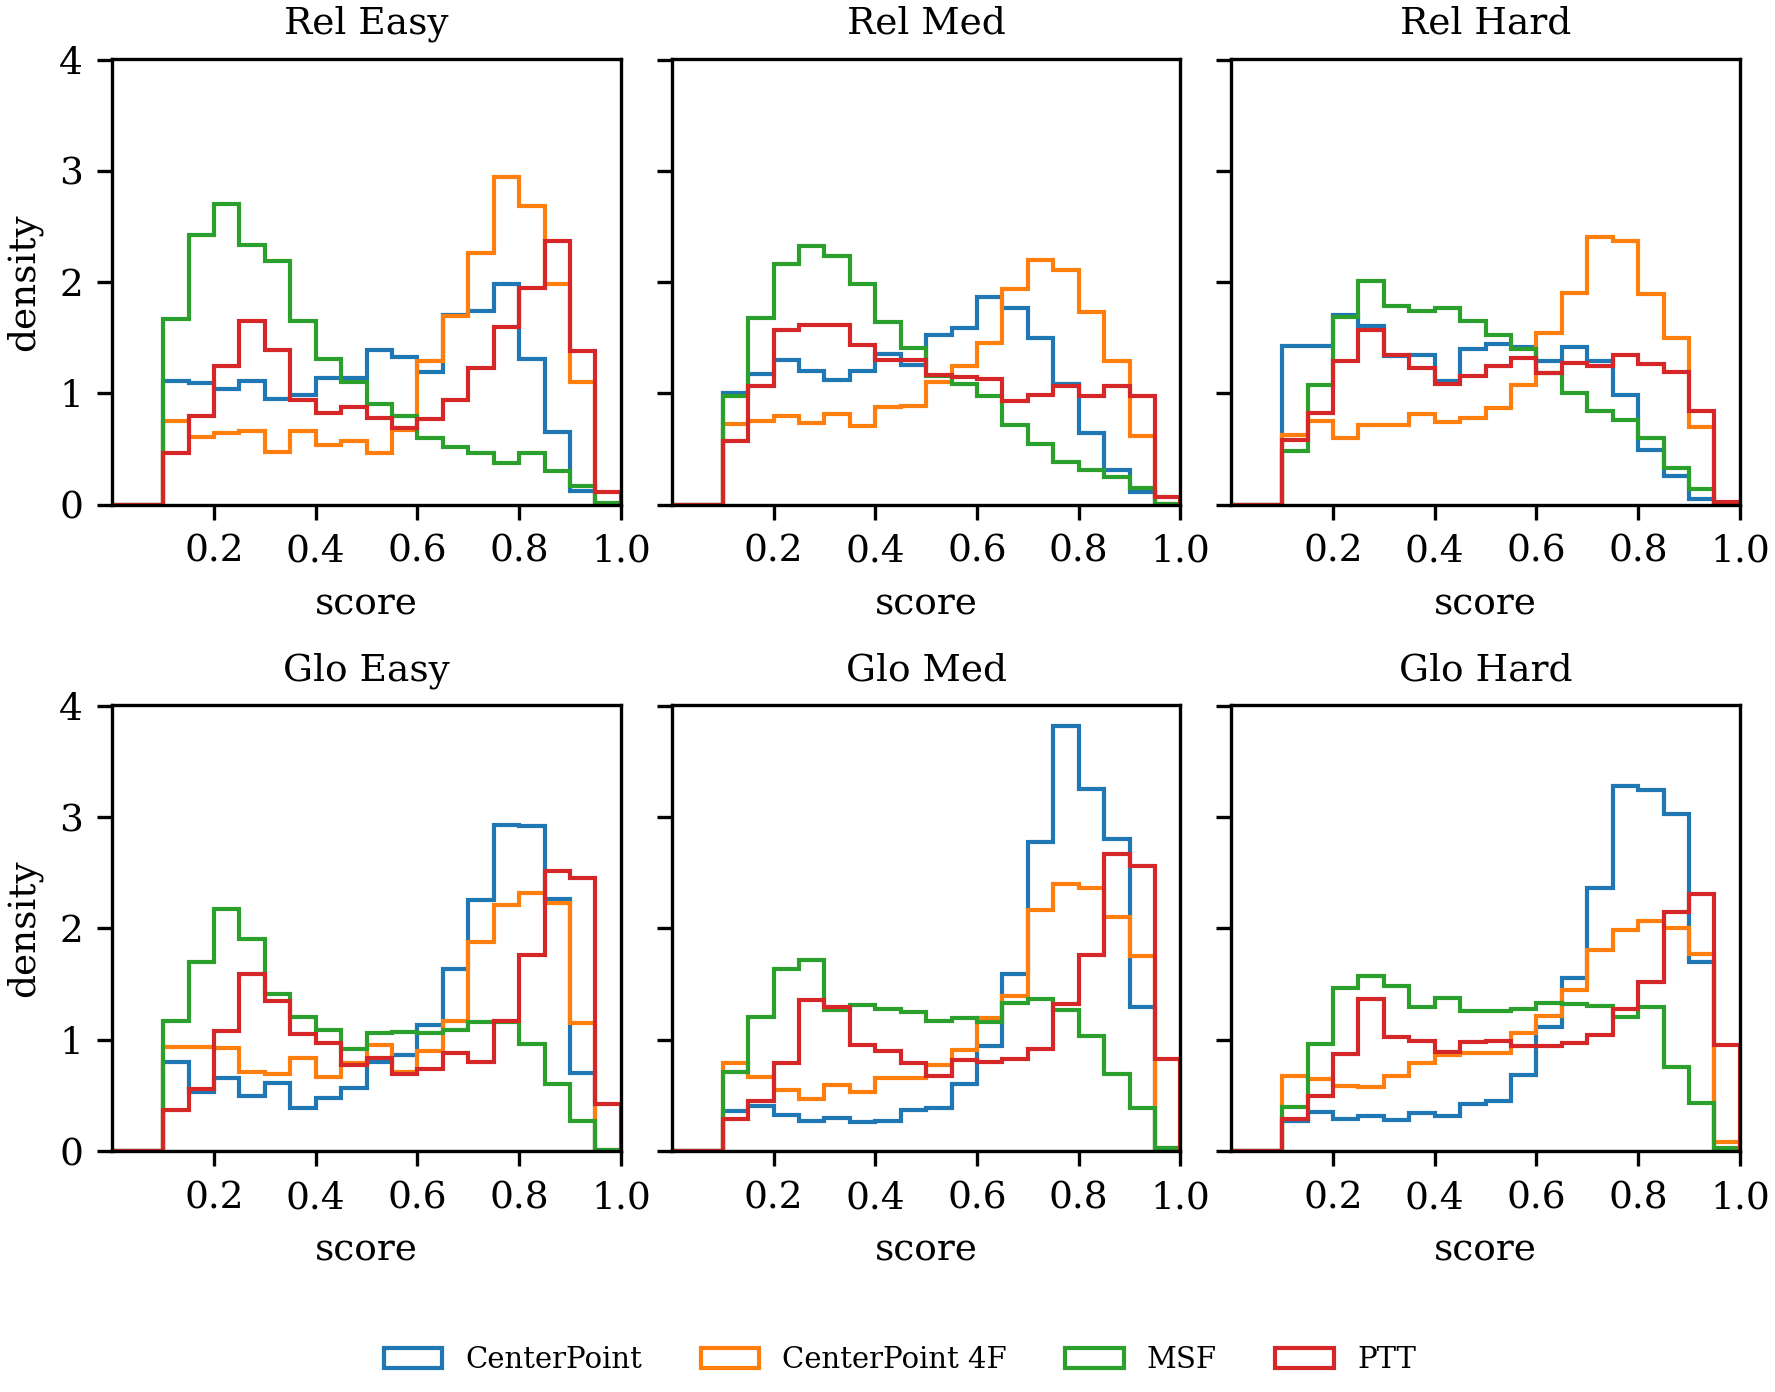

In [14]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fig, axes = plt.subplots(2, 3, figsize=(7,5.2), sharey=True)
rel_modes = ["rel_fixed_easy", "rel_fixed_medium", "rel_fixed_hard"]
global_modes = ["global_easy", "global_medium", "global_hard"]
MODE_LABELS = {
    "rel_fixed_easy":   "Rel Easy",
    "rel_fixed_medium": "Rel Med",
    "rel_fixed_hard":   "Rel Hard",
    "global_easy":      "Glo Easy",
    "global_medium":    "Glo Med",
    "global_hard":      "Glo Hard",
}
def norm_hist(ax, scores, bins, label):
    if len(scores) == 0:
        return
    ax.hist(scores, bins=bins, density=True,
            histtype="step", linewidth=1.0, label=label)

for row, mode_list in enumerate([rel_modes, global_modes]):
    for col, mode in enumerate(mode_list):
        ax = axes[row, col]

        cp_scores, cp4f_scores, msf_scores, ptt_scores = [], [], [], []

        for entry in global_asr:
            if entry["name"] == f"cp_{mode}":
                cp_scores = entry["scores_vehicle"]
            if entry["name"] == f"cp4f_{mode}":
                cp4f_scores = entry["scores_vehicle"]
            if entry["name"] == f"msf_{mode}":
                msf_scores = entry["scores_vehicle"]
            if entry["name"] == f"ptt_{mode}":
                ptt_scores = entry["scores_vehicle"]

        # thinner lines
        norm_hist(ax, cp_scores, bins, "CenterPoint")
        norm_hist(ax, cp4f_scores, bins, "CenterPoint 4F")
        norm_hist(ax, msf_scores, bins, "MSF")
        norm_hist(ax, ptt_scores, bins, "PTT")

        # smaller text everywhere
        # ax.set_title(mode, fontsize=7, pad=2)
        ax.set_xlim(0,1)
        # ax.set_xlabel("score", fontsize=7)
        # ax.tick_params(labelsize=6)
        ax.set_title(MODE_LABELS[mode], fontsize=9)
        ax.set_xlabel("score", fontsize=9)
        ax.tick_params(labelsize=9)
    for ax in axes.flat:
        ax.set_xticks(np.arange(0.2, 1.01, 0.2))
axes[0,0].set_ylabel("density", fontsize=9)
axes[1,0].set_ylabel("density", fontsize=9)

for ax in axes.flat:
    for line in ax.lines:
        line.set_linewidth(1.0)
        
# ax.set_title(mode, fontsize=8)
# ax.set_xlabel("score", fontsize=8)
# ax.tick_params(labelsize=7)

# tighter spacing + MUCH smaller bottom margin
plt.subplots_adjust(wspace=0.10, hspace=0.45, bottom=0.18)

# compact legend just under plots
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center',
           bbox_to_anchor=(0.5, 0.02),  # pull it way up
           ncol=4,
           fontsize=7,
           frameon=False)
plt.savefig("data/global_score_dist.pdf", bbox_inches="tight")
plt.show()


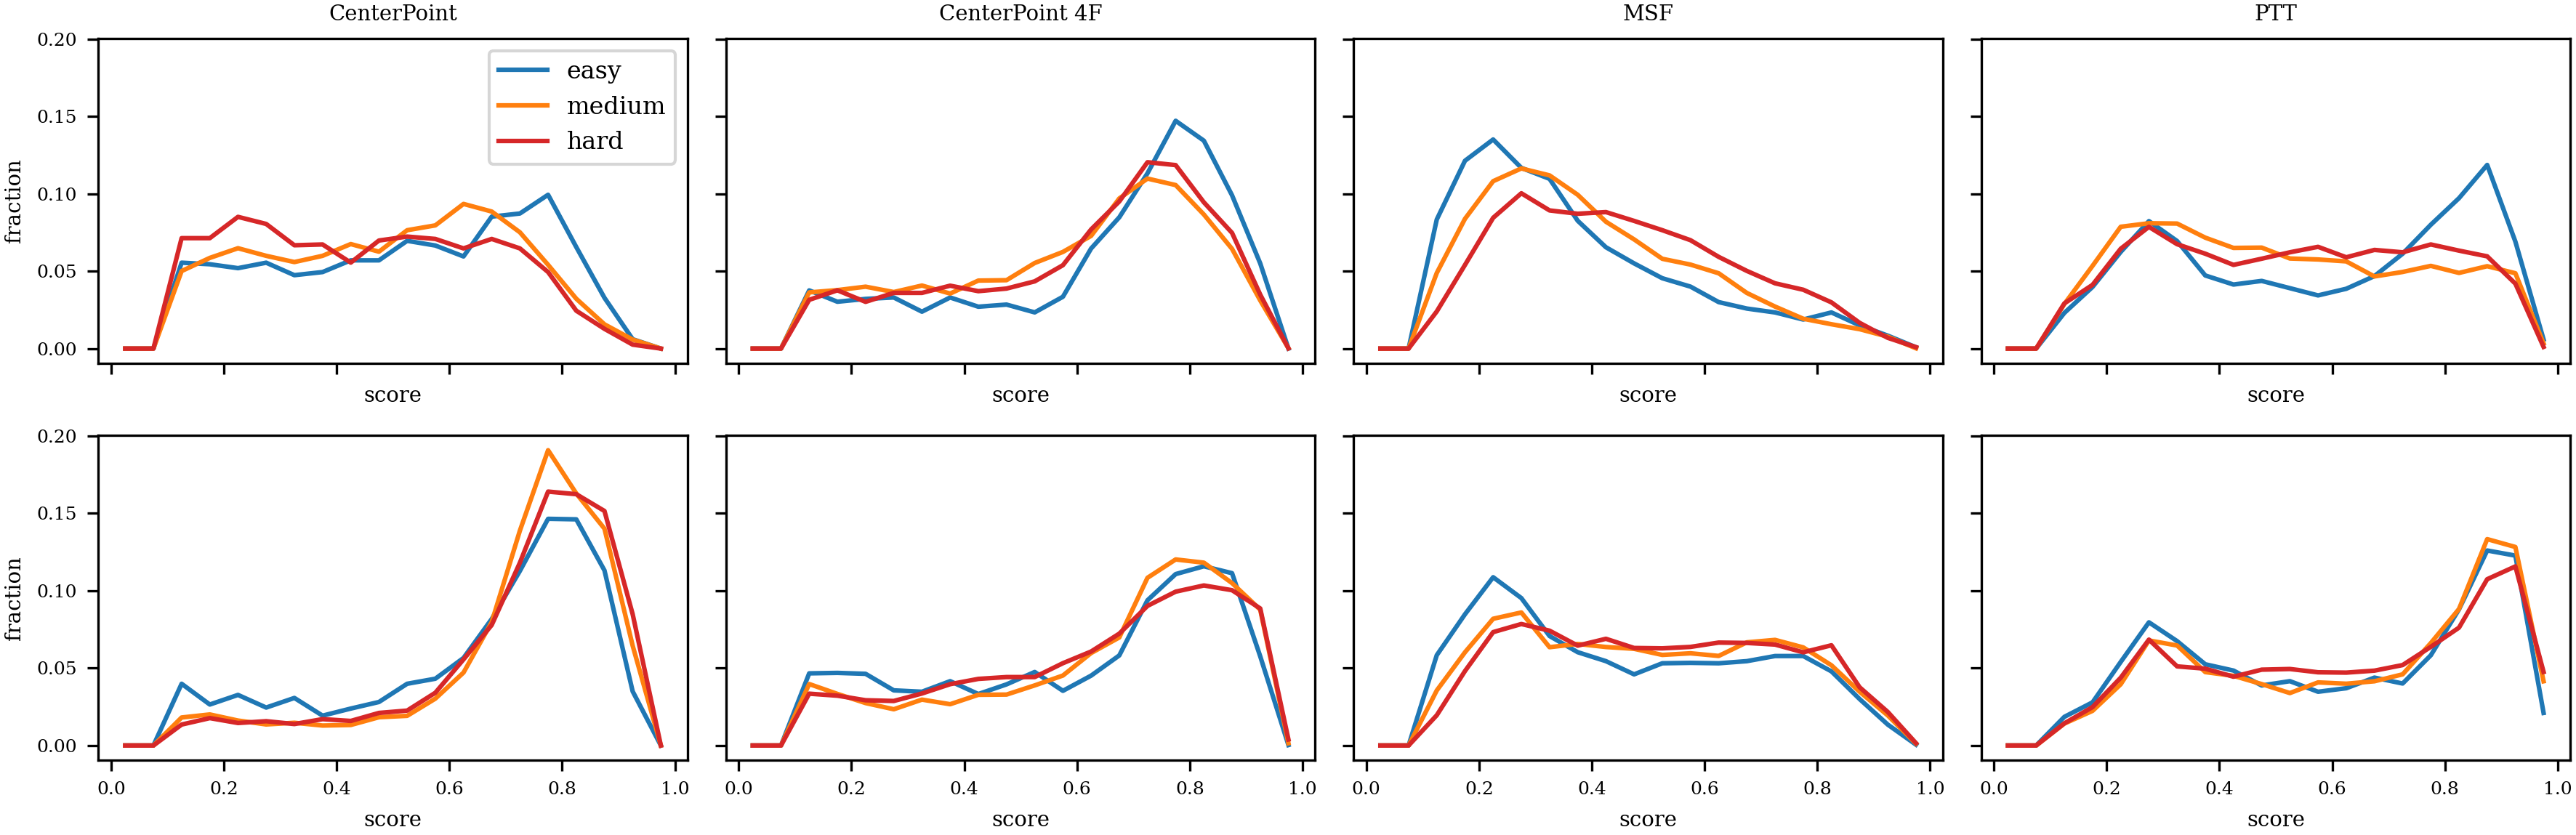

In [15]:
def norm_hist_line(ax, scores, bins, label, **kwargs):
    hist, edges = np.histogram(scores, bins=bins)
    hist = hist / (hist.sum() + 1e-12)
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.plot(centers, hist, label=label, **kwargs)
fig, axes = plt.subplots(2, 4, figsize=(12,4), sharex=True, sharey=True)

detectors = ["cp", "cp4f", "msf", "ptt"]
name_map = {
    "cp": "CenterPoint",
    "cp4f": "CenterPoint 4F",
    "msf": "MSF",
    "ptt": "PTT"
}

difficulties = ["easy", "medium", "hard"]
colors = ["tab:blue", "tab:orange", "tab:red"]

for col, det in enumerate(detectors):
    for row, attack_type in enumerate(["rel_fixed", "global"]):
        ax = axes[row, col]

        for diff, c in zip(difficulties, colors):
            scores = []
            for entry in global_asr:
                if entry["name"] == f"{det}_{attack_type}_{diff}":
                    scores = entry["scores_vehicle"]

            norm_hist_line(ax, scores, bins,
                           label=diff, linestyle='-', color=c)

        if row == 0:
            ax.set_title(name_map[det])

        if col == 0:
            ax.set_ylabel("fraction")

        ax.set_xlabel("score")

axes[0,0].legend(fontsize=8)
plt.tight_layout()
plt.show()

What the above plots are showing: Of the fals positives, what % fall within a certain range of confidence scores? Example interpretation: ~18% of false positives detected by centerpoint single frame have a score between 0.75-0.8.

### CP4F

In [16]:
def load_local_metrics(file):
    with open(file, 'rb') as f:
        data = pkl.load(f)

    data = sorted(data, key=lambda x: x["k"])

    ks = []
    num_frames = []
    asr = []
    ap = []
    asr_records = []

    for entry in data:
        # print(entry.keys())
        # break
        ks.append(entry["k"])
        num_frames.append(entry["num_frames"])
        asr.append(entry["asr"])
        ap.append(entry['ap'])
        asr_records.append(entry["asr_records"])

    return ks, num_frames, asr, asr_records, ap 

ks, num_frames, asr, asr_records, ap = load_local_metrics(local_metrics_files_cp4f[0])

import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import os

def load_local_metrics(file):
    with open(file, 'rb') as f:
        data = pkl.load(f)

    data = sorted(data, key=lambda x: x["k"])

    ks = []
    num_frames = []
    asr = []
    ap = []
    asr_records = []

    for entry in data:
        ks.append(entry["k"])
        num_frames.append(entry["num_frames"])
        asr.append(entry["asr"])
        ap.append(entry["ap"])
        asr_records.append(entry["asr_records"])

    return ks, num_frames, asr, ap, asr_records


results = {}

for f in local_metrics_files_cp4f:
    name = os.path.basename(f).replace("_local.json","")
    ks, num_frames, asr, ap, asr_records = load_local_metrics(f)

    results[name] = {
        "k": ks,
        "num_frames": num_frames,
        "asr": asr,
        "ap": ap,
        "records": asr_records
    }
mode_order = {
    "rel_fixed_easy":0,
    "rel_fixed_medium":1,
    "rel_fixed_hard":2,
    "global_easy":3,
    "global_medium":4,
    "global_hard":5
}

results = dict(
    sorted(
        results.items(),
        key=lambda x: mode_order[x[0].replace("cp4f_","")]
    )
)

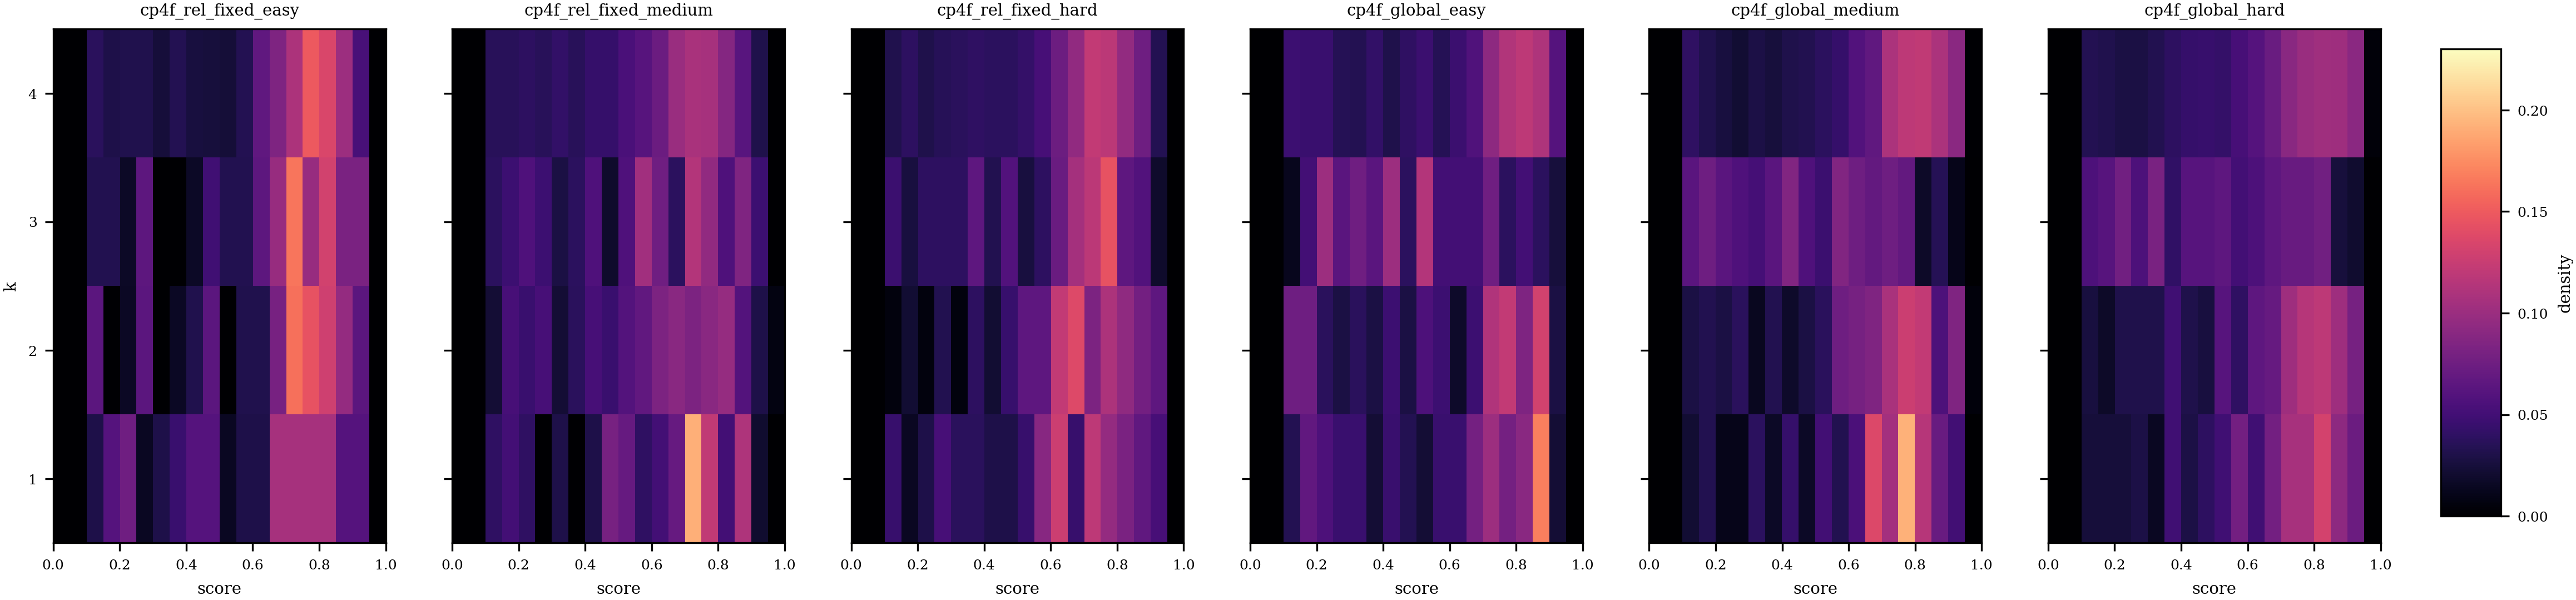

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

global_max = 0
heatmaps = {}

for name, r in results.items():
    hm = []
    for k, recs in zip(r["k"], r["records"]):
        if k == 0:
            continue
        scores = np.array([x["score"] for x in recs])
        hist, _ = np.histogram(scores, bins=bins, density=True)
        hm.append(hist)
    hm = np.array(hm)

    # col_sums = hm.sum(axis=0, keepdims=True) + 1e-12
    # hm = hm / col_sums   # overwrite
    row_sums = hm.sum(axis=1, keepdims=True) + 1e-12
    hm = hm / row_sums

    heatmaps[name] = hm
    global_max = max(global_max, hm.max())
    

fig, axes = plt.subplots(1, 6, figsize=(18,4), sharey=True)
fig.subplots_adjust(right=0.9)

cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]

for ax, (name, hm) in zip(axes, heatmaps.items()):
    im = ax.imshow(hm, aspect="auto", origin="lower", cmap="magma",
               vmin=0, vmax=0.23,
               extent=[bins[0], bins[-1], 0.5, hm.shape[0] + 0.5])
    ax.set_yticks([1,2,3,4])
    ax.set_yticklabels([1,2,3,4])
    ax.set_title(name)
    ax.set_xlabel("score")
    if name=="cp4f_rel_fixed_easy":
        ax.set_ylabel("k")

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("density")

Saved → data/fig_cp4f_history.pdf


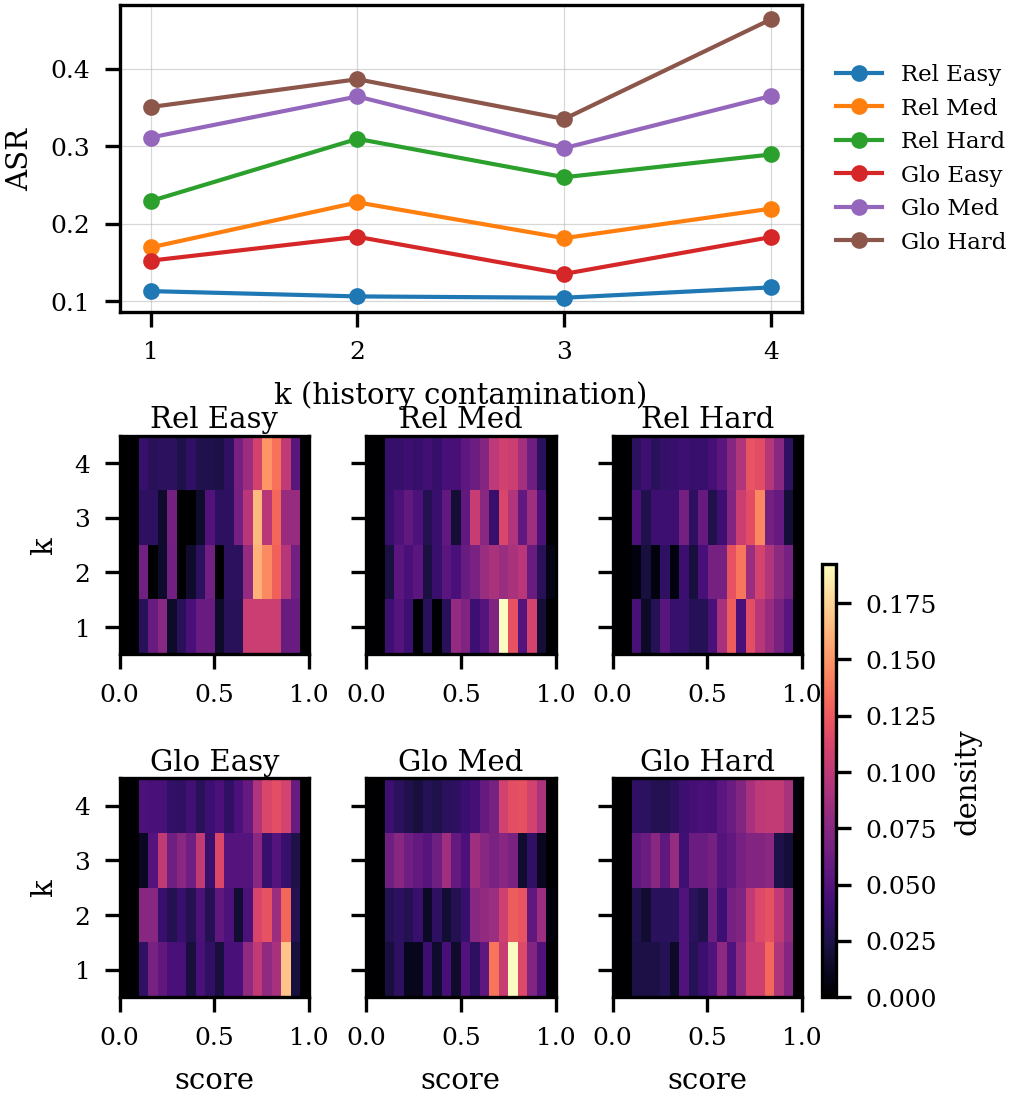

In [18]:
plot_4frame_combined(results, "cp4f", save_path="data/fig_cp4f_history.pdf")

In [19]:
# plt.figure(figsize=(7,5))

# for name, r in results.items():
#     ks = np.array(r["k"])
#     asr = np.array(r["asr"])

#     mask = ks > 0
#     plt.plot(ks[mask], asr[mask], marker='o', label=name)

# plt.xlabel("k (history contamination)")
# plt.ylabel("ASR")
# plt.title("ASR vs history contamination")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.xticks(range(min(ks), max(ks)+1))
# plt.show()

# plt.figure(figsize=(7,5))

# for name, r in results.items():

#     ks = r["k"]
#     veh_l1 = []
#     veh_l1h = []

#     for metrics in r["ap"]:
#         v = vehicle_ap_aph(metrics)
#         veh_l1.append(v[0])
#         veh_l1h.append(v[1])

#     plt.plot(ks, veh_l1, marker='o', label=name+" L1 AP")

# plt.xlabel("k")
# plt.ylabel("Vehicle L1 AP (%)")
# plt.title("Vehicle AP vs history contamination")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.xticks(range(min(ks), max(ks)+1))
# plt.show()

# plt.figure(figsize=(7,5))

# for name, r in results.items():

#     ks = r["k"]

#     l1map = []
#     l1maph = []

#     for metrics in r["ap"]:
#         m = overall_map_maph(metrics)
#         l1map.append(m[0])
#         l1maph.append(m[1])

#     plt.plot(ks, l1map, marker='o', label=name)

# plt.xlabel("k")
# plt.ylabel("L1 mAP (%)")
# plt.title("mAP vs history contamination")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()

# plt.xticks(range(min(ks), max(ks)+1))
# plt.show()

### MSF

In [20]:
def load_local_metrics(file):
    with open(file, 'rb') as f:
        data = pkl.load(f)

    data = sorted(data, key=lambda x: x["k"])

    ks = []
    num_frames = []
    asr = []
    ap = []
    asr_records = []

    for entry in data:
        # print(entry.keys())
        # break
        ks.append(entry["k"])
        num_frames.append(entry["num_frames"])
        asr.append(entry["asr"])
        ap.append(entry['ap'])
        asr_records.append(entry["asr_records"])

    return ks, num_frames, asr, asr_records, ap 

ks, num_frames, asr, asr_records, ap = load_local_metrics(local_metrics_files_msf[0])

import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import os

def load_local_metrics(file):
    with open(file, 'rb') as f:
        data = pkl.load(f)

    data = sorted(data, key=lambda x: x["k"])

    ks = []
    num_frames = []
    asr = []
    ap = []
    asr_records = []

    for entry in data:
        ks.append(entry["k"])
        num_frames.append(entry["num_frames"])
        asr.append(entry["asr"])
        ap.append(entry["ap"])
        asr_records.append(entry["asr_records"])

    return ks, num_frames, asr, ap, asr_records


results = {}

for f in local_metrics_files_msf:
    name = os.path.basename(f).replace("_local.json","")
    ks, num_frames, asr, ap, asr_records = load_local_metrics(f)

    results[name] = {
        "k": ks,
        "num_frames": num_frames,
        "asr": asr,
        "ap": ap,
        "records": asr_records
    }
mode_order = {
    "rel_fixed_easy":0,
    "rel_fixed_medium":1,
    "rel_fixed_hard":2,
    "global_easy":3,
    "global_medium":4,
    "global_hard":5
}

results = dict(
    sorted(
        results.items(),
        key=lambda x: mode_order[x[0].replace("msf_","")]
    )
)

# normalize over k: which k dominates different score ranges; do high confidence detections come from a larger k?

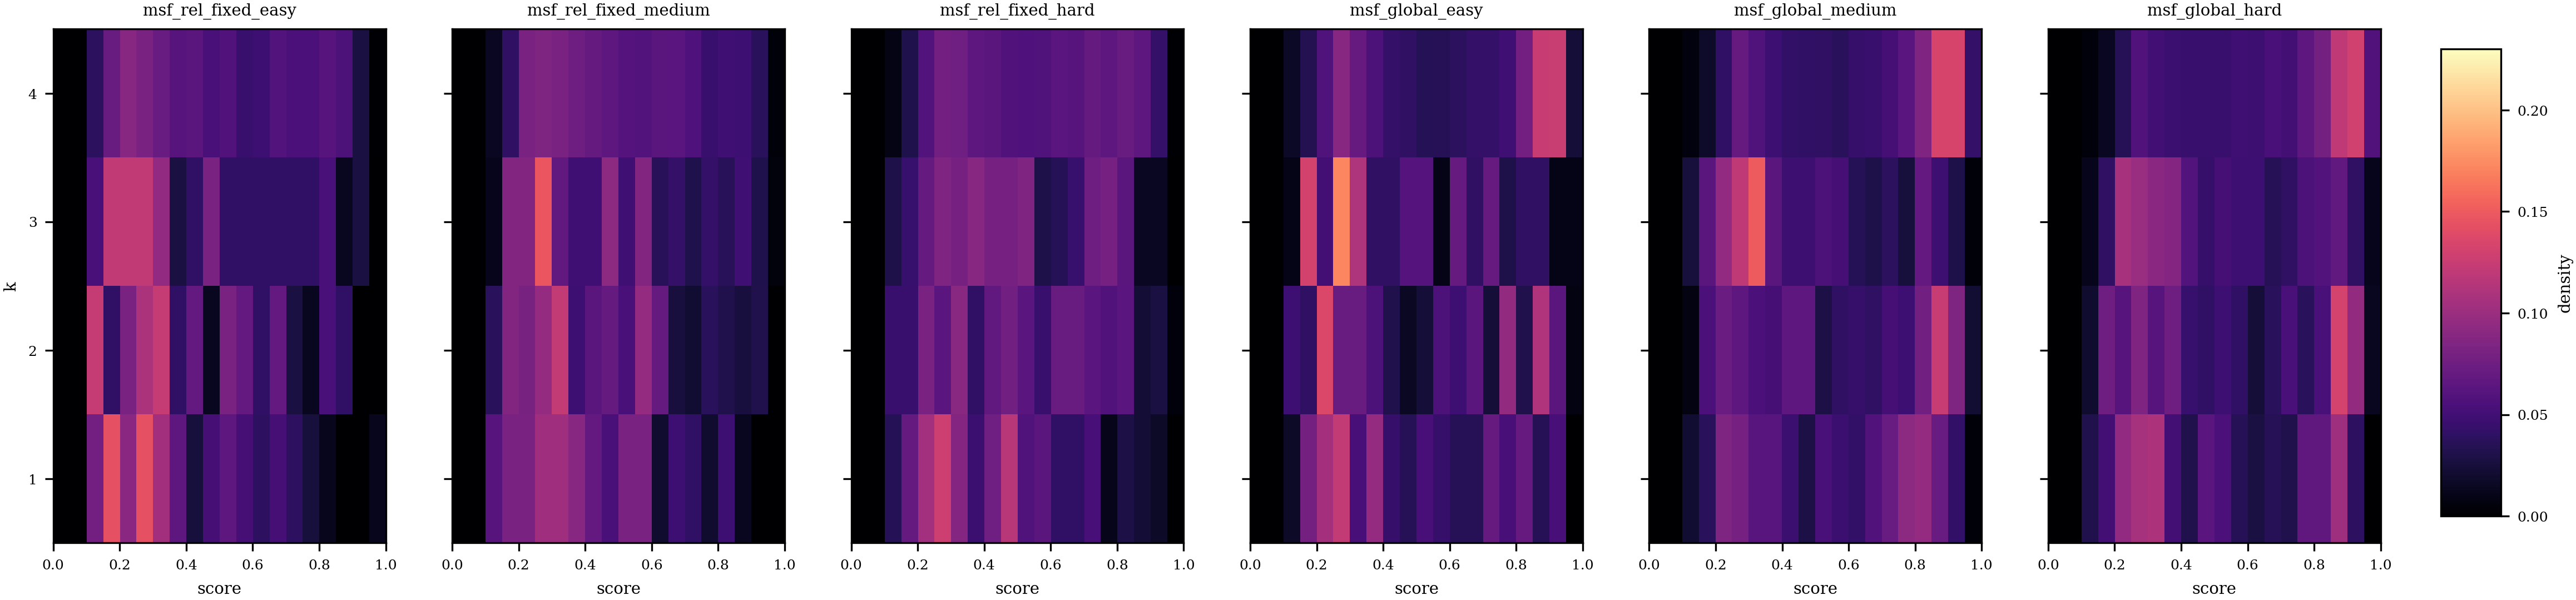

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

global_max = 0
heatmaps = {}

for name, r in results.items():
    hm = []
    for k, recs in zip(r["k"], r["records"]):
        if k == 0:
            continue
        scores = np.array([x["score"] for x in recs])
        hist, _ = np.histogram(scores, bins=bins, density=True)
        hm.append(hist)
    hm = np.array(hm)

    # col_sums = hm.sum(axis=0, keepdims=True) + 1e-12
    # hm = hm / col_sums   # overwrite
    row_sums = hm.sum(axis=1, keepdims=True) + 1e-12
    hm = hm / row_sums

    heatmaps[name] = hm
    global_max = max(global_max, hm.max())
    

fig, axes = plt.subplots(1, 6, figsize=(18,4), sharey=True)
fig.subplots_adjust(right=0.9)

cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]

for ax, (name, hm) in zip(axes, heatmaps.items()):
    im = ax.imshow(hm, aspect="auto", origin="lower", cmap="magma",
               vmin=0, vmax=0.23,
               extent=[bins[0], bins[-1], 0.5, hm.shape[0] + 0.5])
    ax.set_yticks([1,2,3,4])
    ax.set_yticklabels([1,2,3,4])
    ax.set_title(name)
    ax.set_xlabel("score")
    if name=="msf_rel_fixed_easy":
        ax.set_ylabel("k")

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("density")

Saved → data/fig_msf_history.pdf


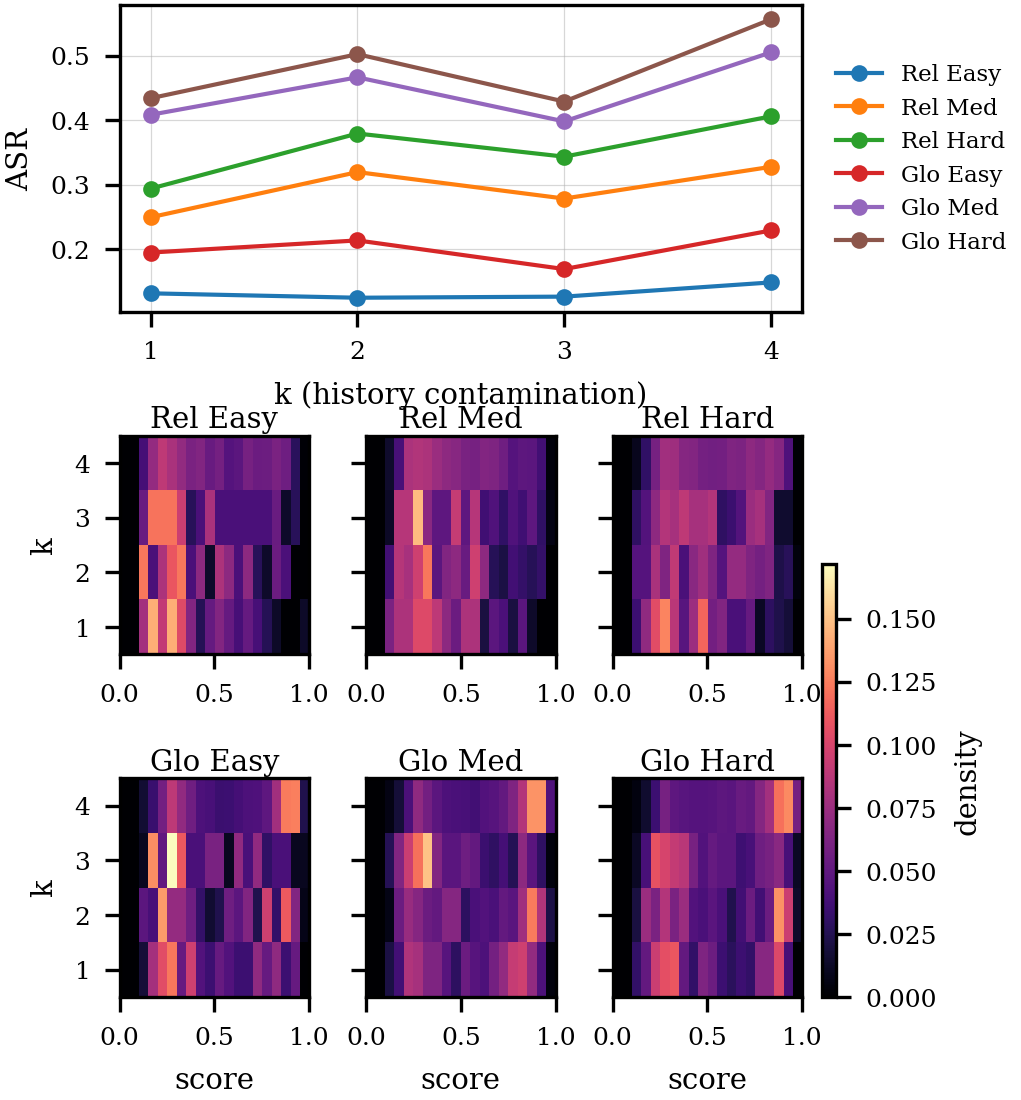

In [22]:
plot_4frame_combined(results, "msf",  save_path="data/fig_msf_history.pdf")

In [23]:
# plt.figure(figsize=(7,5))

# for name, r in results.items():
#     ks = np.array(r["k"])
#     asr = np.array(r["asr"])

#     mask = ks > 0
#     plt.plot(ks[mask], asr[mask], marker='o', label=name)

# plt.xlabel("k (history contamination)")
# plt.ylabel("ASR")
# plt.title("ASR vs history contamination")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.xticks(range(min(ks), max(ks)+1))
# plt.show()

# plt.figure(figsize=(7,5))

# for name, r in results.items():

#     ks = r["k"]
#     veh_l1 = []
#     veh_l1h = []

#     for metrics in r["ap"]:
#         v = vehicle_ap_aph(metrics)
#         veh_l1.append(v[0])
#         veh_l1h.append(v[1])

#     plt.plot(ks, veh_l1, marker='o', label=name+" L1 AP")

# plt.xlabel("k")
# plt.ylabel("Vehicle L1 AP (%)")
# plt.title("Vehicle AP vs history contamination")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.xticks(range(min(ks), max(ks)+1))
# plt.show()

# plt.figure(figsize=(7,5))

# for name, r in results.items():

#     ks = r["k"]

#     l1map = []
#     l1maph = []

#     for metrics in r["ap"]:
#         m = overall_map_maph(metrics)
#         l1map.append(m[0])
#         l1maph.append(m[1])

#     plt.plot(ks, l1map, marker='o', label=name)

# plt.xlabel("k")
# plt.ylabel("L1 mAP (%)")
# plt.title("mAP vs history contamination")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()

# plt.xticks(range(min(ks), max(ks)+1))
# plt.show()

In [24]:
# import numpy as np
# import matplotlib.pyplot as plt

# bins = np.arange(0, 1.05, 0.05)

# fig, axes = plt.subplots(1, 6, figsize=(18,4), sharex=True, sharey=True)

# for ax, (name, r) in zip(axes, results.items()):

#     for i, k in enumerate([1,2,3,4]):

#         idx = r["k"].index(k)
#         scores = [x["score"] for x in r["records"][idx]]

#         ax.hist(
#             scores,
#             bins=bins,
#             density=True,
#             histtype="step",   # outline histogram (no filling)
#             linewidth=2,
#             label=f"k={k}"
#         )

#     ax.set_title(name)
#     ax.set_xlim(0,1)
#     ax.grid(True)

# axes[0].set_ylabel("density")

# for ax in axes:
#     ax.set_xlabel("score")

# axes[-1].legend()

# plt.suptitle("Spoof detection score distributions")
# plt.tight_layout()
# plt.show()

### PTT

In [25]:
results = {}

for f in local_metrics_files_ptt:
    name = os.path.basename(f).replace("_local.json","")
    ks, num_frames, asr, ap, asr_records = load_local_metrics(f)

    results[name] = {
        "k": ks,
        "num_frames": num_frames,
        "asr": asr,
        "ap": ap,
        "records": asr_records
    }
mode_order = {
    "rel_fixed_easy":0,
    "rel_fixed_medium":1,
    "rel_fixed_hard":2,
    "global_easy":3,
    "global_medium":4,
    "global_hard":5
}

results = dict(
    sorted(
        results.items(),
        key=lambda x: mode_order[x[0].replace("ptt_","")]
    )
)



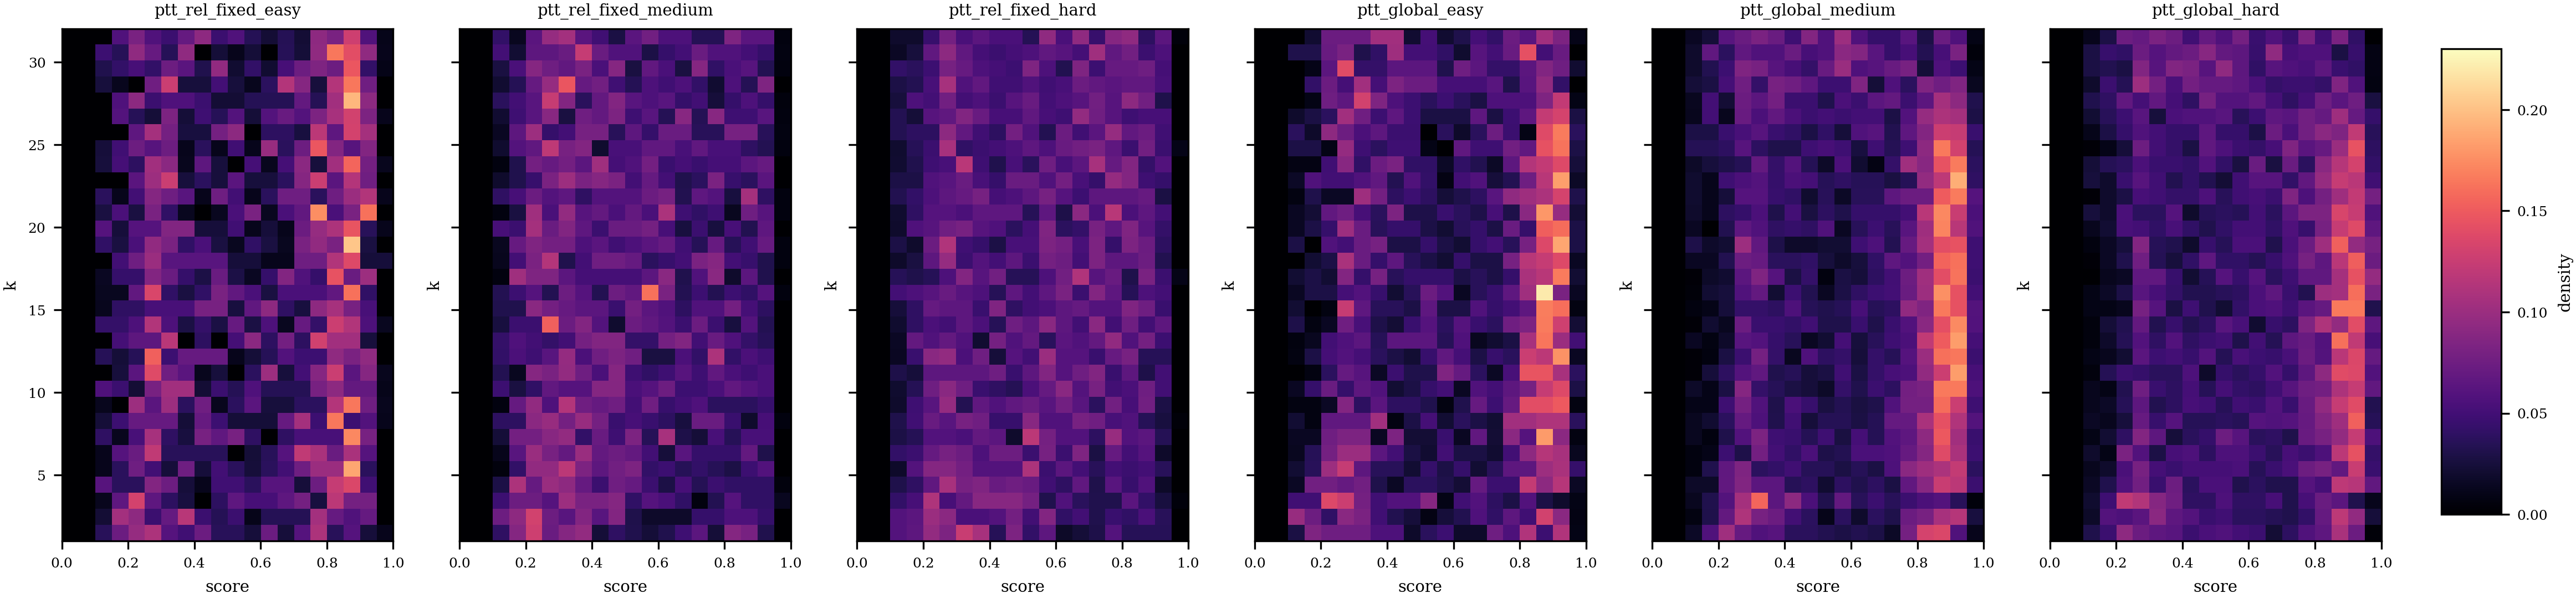

In [26]:
import numpy as np
import matplotlib.pyplot as plt

global_max = 0
heatmaps = {}

for name, r in results.items():
    hm = []
    for k, recs in zip(r["k"], r["records"]):
        if k == 0:
            continue
        scores = np.array([x["score"] for x in recs])
        # hist, _ = np.histogram(scores, bins=bins, density=True)
        hist, _ = np.histogram(scores, bins=bins, density=False)
        hm.append(hist)
    hm = np.array(hm)
    # heatmaps[name] = hm
    # global_max = max(global_max, hm.max())
    hm = np.array(hm)

    # normalize per k (row-wise)
    hm = hm / (hm.sum(axis=1, keepdims=True) + 1e-12)
    heatmaps[name] = hm
    global_max = max(global_max, hm.max())

fig, axes = plt.subplots(1, 6, figsize=(18,4), sharey=True)
fig.subplots_adjust(right=0.9)

cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]

for ax, (name, hm) in zip(axes, heatmaps.items()):
    im = ax.imshow(hm, aspect="auto", origin="lower", cmap="magma",
                   vmin=0, vmax=0.23,
                   extent=[bins[0], bins[-1], 1, hm.shape[0]])
    ax.set_title(name)
    ax.set_xlabel("score")
    ax.set_ylabel("k")

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("density")

Saved → data/fig_ptt_history.pdf


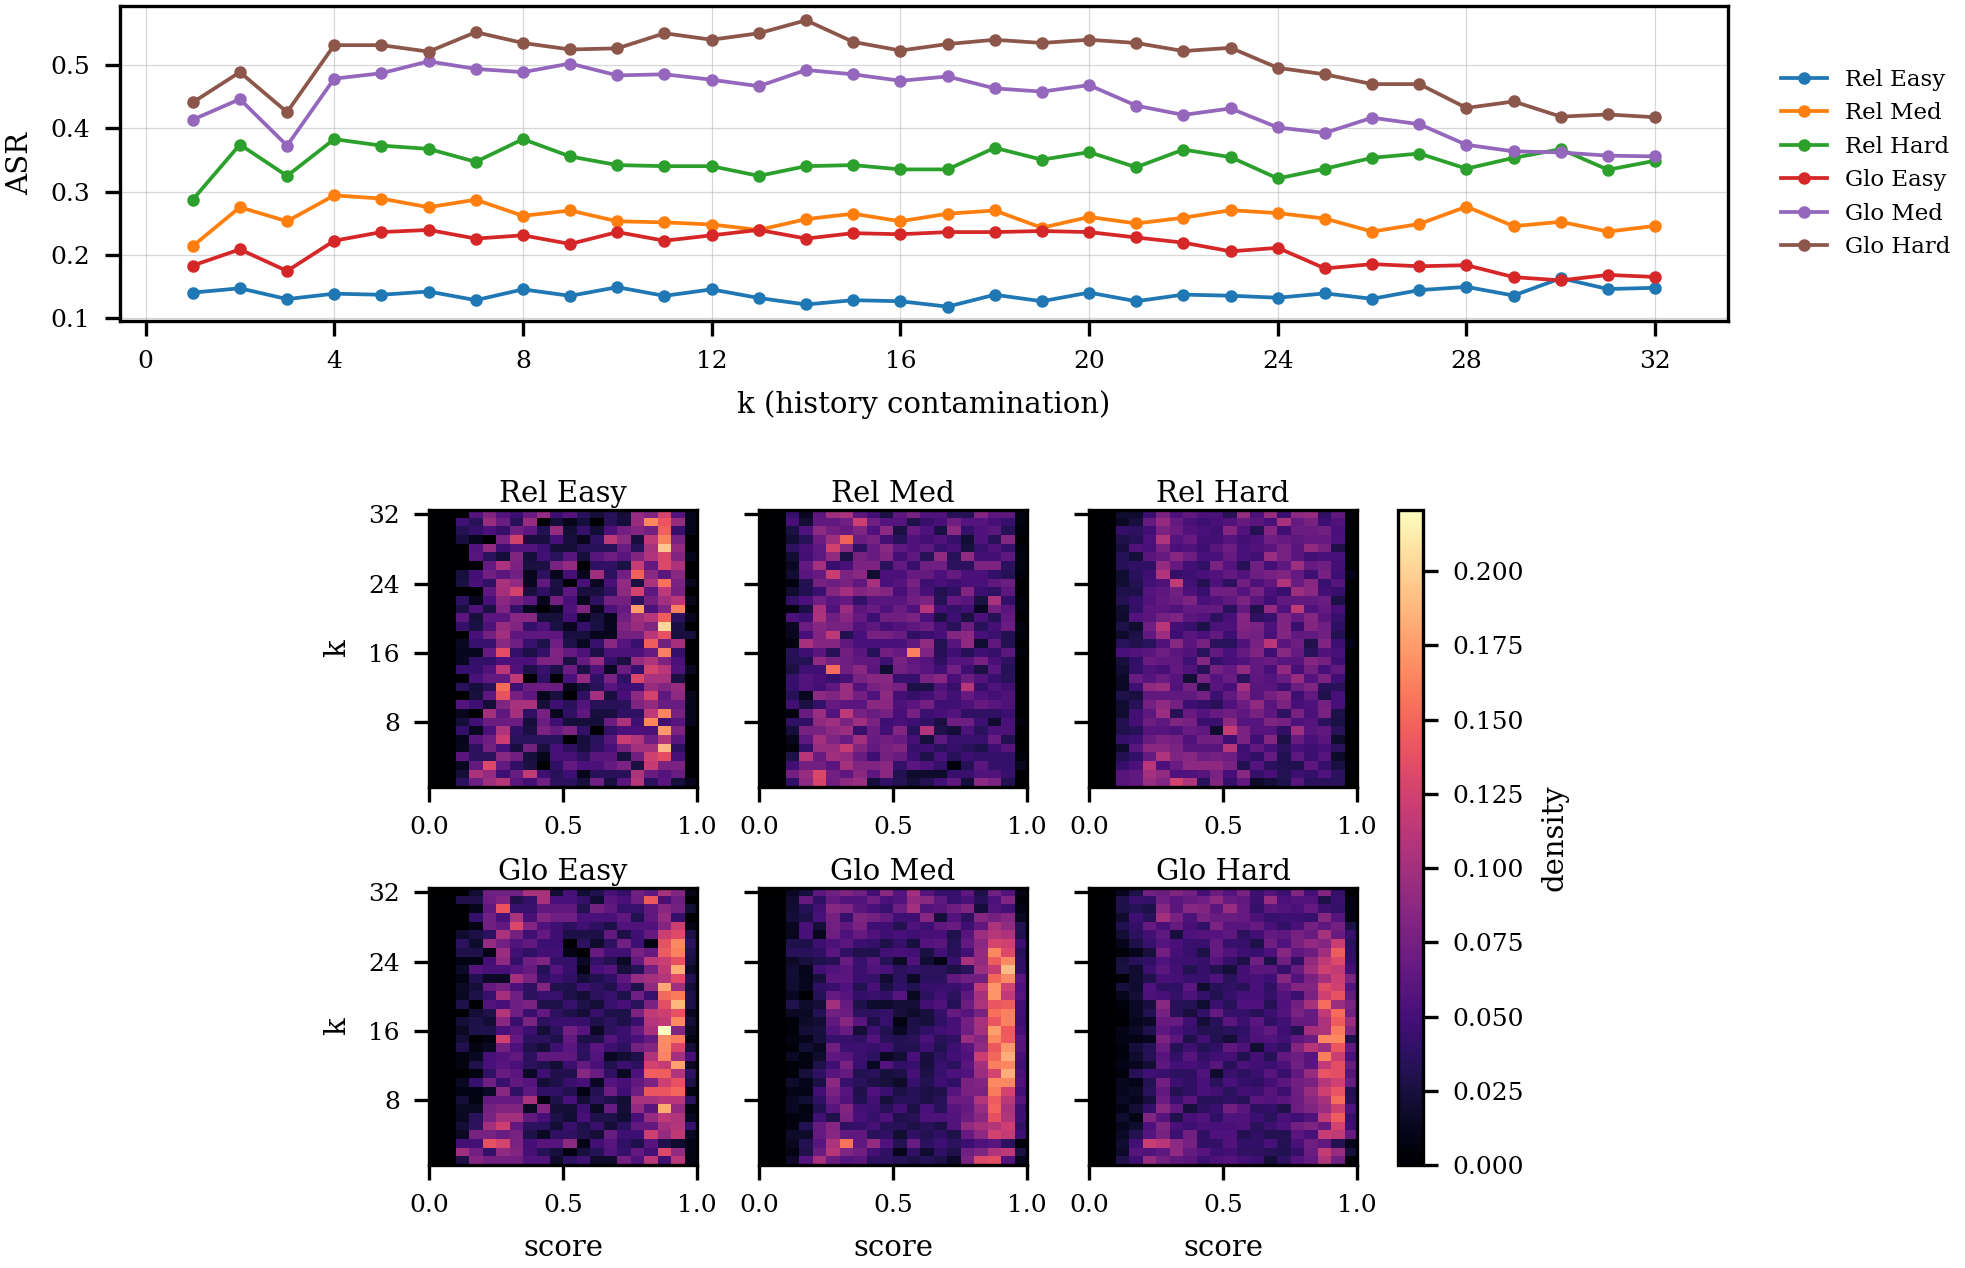

In [27]:
plot_ptt_combined(results,            save_path="data/fig_ptt_history.pdf")

In [28]:
# plt.figure(figsize=(10,5))

# for name, r in results.items():
#     ks = np.array(r["k"])
#     asr = np.array(r["asr"])

#     mask = ks > 0
#     plt.plot(ks[mask], asr[mask], marker='o', label=name)

# plt.xlabel("k (history contamination)")
# plt.ylabel("ASR")
# plt.title("ASR vs history contamination")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.xticks(range(min(ks), max(ks)+1))
# plt.show()

# plt.figure(figsize=(10,5))

# for name, r in results.items():

#     ks = r["k"]
#     veh_l1 = []
#     veh_l1h = []

#     for metrics in r["ap"]:
#         v = vehicle_ap_aph(metrics)
#         veh_l1.append(v[0])
#         veh_l1h.append(v[1])

#     plt.plot(ks, veh_l1, marker='o', label=name+" L1 AP")

# # plt.xlabel("k")
# # plt.ylabel("Vehicle L1 AP (%)")
# # plt.title("Vehicle AP vs history contamination")
# # plt.legend()
# # plt.grid(True)
# # plt.tight_layout()
# # plt.xticks(range(min(ks), max(ks)+1))
# # plt.show()

# # plt.figure(figsize=(10,5))

# # for name, r in results.items():

# #     ks = r["k"]

# #     l1map = []
# #     l1maph = []

# #     for metrics in r["ap"]:
# #         m = overall_map_maph(metrics)
# #         l1map.append(m[0])
# #         l1maph.append(m[1])

# #     plt.plot(ks, l1map, marker='o', label=name)

# # plt.xlabel("k")
# # plt.ylabel("L1 mAP (%)")
# # plt.title("mAP vs history contamination")
# # plt.legend()
# # plt.grid(True)
# # plt.tight_layout()

# # plt.xticks(range(min(ks), max(ks)+1))
# # plt.show()

# for a given k and score bin, the color represents what fraction of detections at that k fall into that score bin

# normalize over k: which k dominates different score ranges; do high confidence detections come from a larger k?